In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sales = pd.read_csv('../../data/M5/sales_train_evaluation.csv')
sales.name = 'sales'
calendar = pd.read_csv('../../data/M5/calendar.csv')
calendar.name = 'calendar'
prices = pd.read_csv('../../data/M5/sell_prices.csv')
prices.name = 'prices'


In [6]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [3]:
for event_col in calendar.filter(like="event").columns:
    calendar[event_col] = calendar[event_col].fillna("no_event")

In [4]:
# reduce memory
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))


In [5]:
reduce_mem_usage(sales)
reduce_mem_usage(calendar)
reduce_mem_usage(prices)

Mem. usage decreased to 96.13 Mb (78.8% reduction)
Mem. usage decreased to  0.12 Mb (41.9% reduction)
Mem. usage decreased to 130.48 Mb (37.5% reduction)


In [6]:
df_sales = pd.melt(sales, id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], var_name='d', value_name='sold').dropna()

In [7]:
df_sales = pd.merge(df_sales, calendar, on='d', how='left')
df_sales = pd.merge(df_sales, prices, on=['store_id','item_id','wm_yr_wk'], how='left') 

In [8]:
df_sales["d"]=df_sales["d"].apply(lambda x: int(x.split("_")[1]))

In [9]:
#Introduce lags
lags = [1,2,3,6,12,24,36]
for lag in lags:
    df_sales['sold_lag_'+str(lag)] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],as_index=False)['sold'].shift(lag).astype(np.float16)

In [10]:
df_sales['iteam_sold_avg'] = df_sales.groupby('item_id')['sold'].transform('mean').astype(np.float16)
df_sales['state_sold_avg'] = df_sales.groupby('state_id')['sold'].transform('mean').astype(np.float16)
df_sales['store_sold_avg'] = df_sales.groupby('store_id')['sold'].transform('mean').astype(np.float16)
df_sales['cat_sold_avg'] = df_sales.groupby('cat_id')['sold'].transform('mean').astype(np.float16)
df_sales['dept_sold_avg'] = df_sales.groupby('dept_id')['sold'].transform('mean').astype(np.float16)
df_sales['cat_dept_sold_avg'] = df_sales.groupby(['cat_id','dept_id'])['sold'].transform('mean').astype(np.float16)
df_sales['store_item_sold_avg'] = df_sales.groupby(['store_id','item_id'])['sold'].transform('mean').astype(np.float16)
df_sales['cat_item_sold_avg'] = df_sales.groupby(['cat_id','item_id'])['sold'].transform('mean').astype(np.float16)
df_sales['dept_item_sold_avg'] = df_sales.groupby(['dept_id','item_id'])['sold'].transform('mean').astype(np.float16)
df_sales['state_store_sold_avg'] = df_sales.groupby(['state_id','store_id'])['sold'].transform('mean').astype(np.float16)
df_sales['state_store_cat_sold_avg'] = df_sales.groupby(['state_id','store_id','cat_id'])['sold'].transform('mean').astype(np.float16)
df_sales['store_cat_dept_sold_avg'] = df_sales.groupby(['store_id','cat_id','dept_id'])['sold'].transform('mean').astype(np.float16)
df_sales['rolling_sold_mean'] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['sold'].transform(lambda x: x.rolling(window=7).mean()).astype(np.float16)
df_sales['expanding_sold_mean'] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['sold'].transform(lambda x: x.expanding(2).mean()).astype(np.float16)

In [11]:
df_sales = df_sales[df_sales['d'] > 36]

In [12]:
df_sales.isnull().sum()

id                                 0
item_id                            0
dept_id                            0
cat_id                             0
store_id                           0
state_id                           0
d                                  0
sold                               0
date                               0
wm_yr_wk                           0
weekday                            0
wday                               0
month                              0
year                               0
event_name_1                       0
event_type_1                       0
event_name_2                       0
event_type_2                       0
snap_CA                            0
snap_TX                            0
snap_WI                            0
sell_price                  11643913
sold_lag_1                         0
sold_lag_2                         0
sold_lag_3                         0
sold_lag_6                         0
sold_lag_12                        0
s

In [13]:
import gc
df_sales = df_sales.drop(['dept_id', 'cat_id','state_id', 'sell_price', 'wm_yr_wk','weekday'], axis=1)
df_sales.to_pickle('data/data_output/preprocessed_data.pkl')
# del df_sales
gc.collect();

In [14]:
# Read data named preprocessed_data
data = pd.read_pickle('data/data_output/preprocessed_data.pkl')

In [15]:
data.head()

,id,item_id,store_id,d,sold,date,wday,month,year,event_name_1,...,dept_sold_avg,cat_dept_sold_avg,store_item_sold_avg,cat_item_sold_avg,dept_item_sold_avg,state_store_sold_avg,state_store_cat_sold_avg,store_cat_dept_sold_avg,rolling_sold_mean,expanding_sold_mean
1097640,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,CA_1,37,0,2011-03-06,2,3,2011,no_event,...,0.705566,0.705566,0.326172,0.219604,0.219604,1.323242,0.813477,1.035156,0.000000,0.000000
1097641,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,CA_1,37,0,2011-03-06,2,3,2011,no_event,...,0.705566,0.705566,0.257568,0.263428,0.263428,1.323242,0.813477,1.035156,0.000000,0.000000
1097642,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,CA_1,37,0,2011-03-06,2,3,2011,no_event,...,0.705566,0.705566,0.159180,0.077820,0.077820,1.323242,0.813477,1.035156,0.000000,0.000000
1097643,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,CA_1,37,2,2011-03-06,2,3,2011,no_event,...,0.705566,0.705566,1.718750,2.041016,2.041016,1.323242,0.813477,1.035156,0.285645,0.054047
1097644,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,CA_1,37,0,2011-03-06,2,3,2011,no_event,...,0.705566,0.705566,0.972656,0.766602,0.766602,1.323242,0.813477,1.035156,0.000000,0.000000


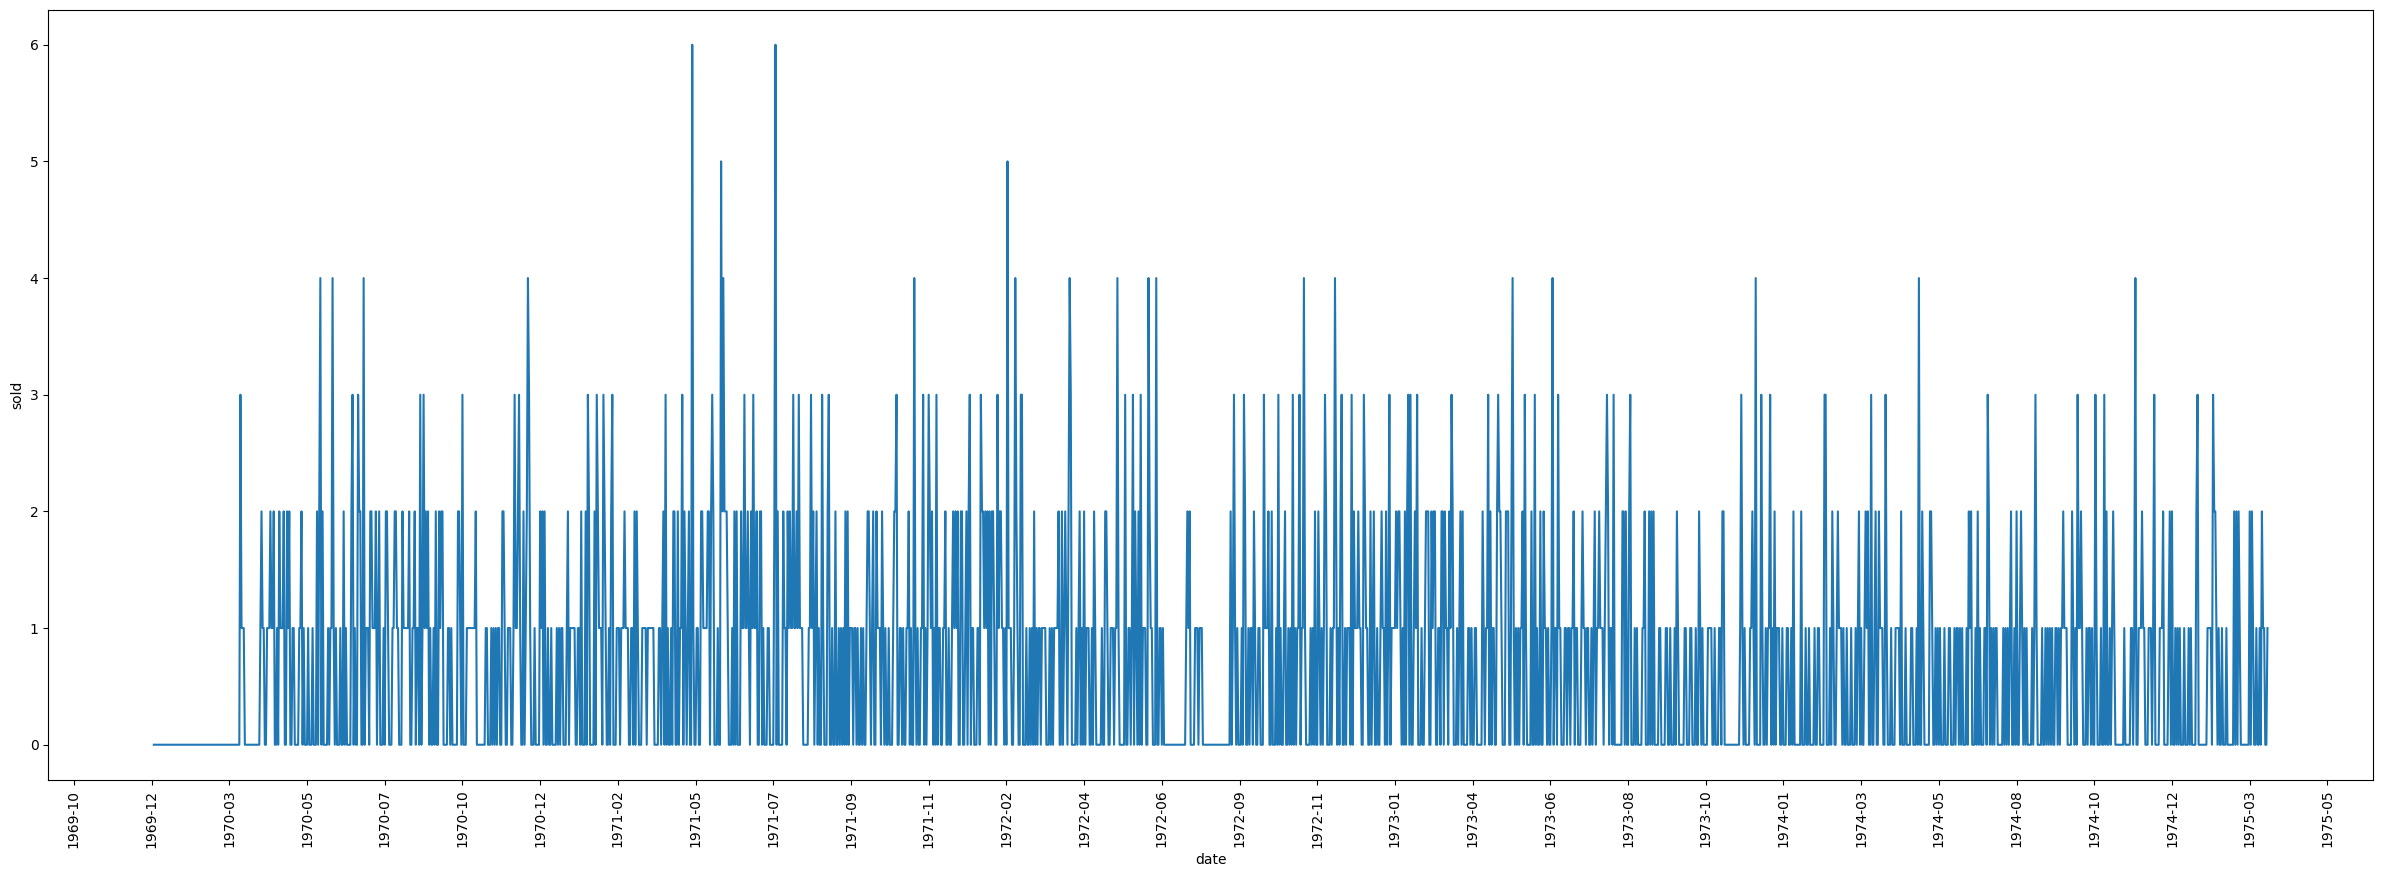

In [16]:
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(30,10))
ax.plot(data[data['id'] == 'HOBBIES_1_010_CA_1_evaluation']['date'],
        data[data['id'] == 'HOBBIES_1_010_CA_1_evaluation']['sold'])
ax.set(xlabel="date", ylabel="sold")
# Format the x axis
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=10))
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
plt.xticks(rotation = 90);

In [17]:
data.isnull().sum()

id                          0
item_id                     0
store_id                    0
d                           0
sold                        0
date                        0
wday                        0
month                       0
year                        0
event_name_1                0
event_type_1                0
event_name_2                0
event_type_2                0
snap_CA                     0
snap_TX                     0
snap_WI                     0
sold_lag_1                  0
sold_lag_2                  0
sold_lag_3                  0
sold_lag_6                  0
sold_lag_12                 0
sold_lag_24                 0
sold_lag_36                 0
iteam_sold_avg              0
state_sold_avg              0
store_sold_avg              0
cat_sold_avg                0
dept_sold_avg               0
cat_dept_sold_avg           0
store_item_sold_avg         0
cat_item_sold_avg           0
dept_item_sold_avg          0
state_store_sold_avg        0
state_stor

In [18]:
data[data['id'] == 'HOBBIES_1_010_CA_1_evaluation']

,id,item_id,store_id,d,sold,date,wday,month,year,event_name_1,...,dept_sold_avg,cat_dept_sold_avg,store_item_sold_avg,cat_item_sold_avg,dept_item_sold_avg,state_store_sold_avg,state_store_cat_sold_avg,store_cat_dept_sold_avg,rolling_sold_mean,expanding_sold_mean
1097649,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,37,0,2011-03-06,2,3,2011,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.000000,0.162109
1128139,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,38,0,2011-03-07,3,3,2011,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.000000,0.157837
1158629,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,39,0,2011-03-08,4,3,2011,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.000000,0.153809
1189119,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,40,0,2011-03-09,5,3,2011,LentStart,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.000000,0.150024
1219609,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,41,0,2011-03-10,6,3,2011,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.000000,0.146362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59028649,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,1937,1,2016-05-18,5,5,2016,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.714355,0.717285
59059139,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,1938,1,2016-05-19,6,5,2016,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.714355,0.717285
59089629,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,1939,0,2016-05-20,7,5,2016,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.714355,0.716797
59120119,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,CA_1,1940,0,2016-05-21,1,5,2016,no_event,...,0.705566,0.705566,0.716797,0.610352,0.610352,1.323242,0.813477,1.035156,0.714355,0.716309


In [19]:
data.columns

Index(['id', 'item_id', 'store_id', 'd', 'sold', 'date', 'wday', 'month',
       'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sold_lag_1', 'sold_lag_2',
       'sold_lag_3', 'sold_lag_6', 'sold_lag_12', 'sold_lag_24', 'sold_lag_36',
       'iteam_sold_avg', 'state_sold_avg', 'store_sold_avg', 'cat_sold_avg',
       'dept_sold_avg', 'cat_dept_sold_avg', 'store_item_sold_avg',
       'cat_item_sold_avg', 'dept_item_sold_avg', 'state_store_sold_avg',
       'state_store_cat_sold_avg', 'store_cat_dept_sold_avg',
       'rolling_sold_mean', 'expanding_sold_mean'],
      dtype='object')

In [2]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import os
from datetime import datetime, timedelta
import pandas as pd
import math
import numpy as np
import random
from tqdm import trange

from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

from math import sqrt
from pandas import read_csv, DataFrame
from scipy import stats

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import datetime as dt


In [3]:
global save_path
name_sales = 'sales_train_evaluation.csv'
name_calendar = 'calendar.csv'
name_prices = 'sell_prices.csv'
save_name = 'M5'
window_size = 192
stride_size = 24
num_covariates = 6
train_start = '2011-01-29 00:00:00'
train_end = '2016-04-24 00:00:00'
test_start = '2016-04-25 00:00:00' #need additional 7 days as given info
test_end = '2016-05-22 00:00:00'
pred_days = 28
given_days = 7

In [4]:
save_path = os.path.join('data', save_name)
if not os.path.exists(save_path):
    os.makedirs(save_path)
sales_csv_path = os.path.join(save_path, name_sales)
calendar_csv_path = os.path.join(save_path, name_calendar)
prices_csv_path = os.path.join(save_path, name_prices)

sales = pd.read_csv('../../data/M5/sales_train_evaluation.csv')
sales.name = 'sales'
calendar = pd.read_csv('../../data/M5/calendar.csv')
calendar.name = 'calendar'
prices = pd.read_csv('../../data/M5/sell_prices.csv')
prices.name = 'prices'

#Create date index
date_index = calendar['date']
dates = date_index[0:1941]
dates_list = [dt.datetime.strptime(date, '%Y-%m-%d').date() for date in dates]

# Create a data frame for items sales per day with item ids (with Store Id) as columns names  and dates as the index 
sales['item_store_id'] = sales.apply(lambda x: x['item_id']+'_'+x['store_id'],axis=1)
data_frame = sales.loc[:,'d_1':'d_1941'].T
data_frame.columns = sales['item_store_id'].values

#Set Dates as index 
data_frame = pd.DataFrame(data_frame).set_index([dates_list])
data_frame.index = pd.to_datetime(data_frame.index)
data_frame.head()

data_frame.shape

(1941, 30490)

In [5]:
def gen_m5_covariates(calendar_df, sales_df):
    # Assuming calendar_df is the calendar DataFrame and sales_df is the sales data DataFrame
    num_covariates = 6  # Example: day of week, month, SNAP_CA, SNAP_TX, SNAP_WI, event
    times = pd.to_datetime(calendar_df['date'])
    covariates = np.zeros((len(times), num_covariates))
    # Day of week and month as numerical values
    covariates[:, 0] = times.dt.dayofweek
    covariates[:, 1] = times.dt.month
    # SNAP days for CA, TX, and WI
    covariates[:, 2] = calendar_df['snap_CA']
    covariates[:, 3] = calendar_df['snap_TX']
    covariates[:, 4] = calendar_df['snap_WI']
    # Event (simple binary indicator for this example)
    covariates[:, 5] = calendar_df[['event_name_1', 'event_name_2']].notnull().any(axis=1).astype(int)
    # Standardize covariates (optional depending on model requirements)
    for i in range(num_covariates):
        covariates[:, i] = (covariates[:, i] - covariates[:, i].mean()) / covariates[:, i].std()
    return covariates

In [6]:
covariates = gen_m5_covariates(calendar, sales)
train_data = data_frame[train_start:train_end].values
test_data = data_frame[test_start:test_end].values
data_start = (train_data!=0).argmax(axis=0) #find first nonzero value in each time series
total_time = data_frame.shape[0] #1941 (days)
num_series = data_frame.shape[1] #30490 (item_id)
covariates = covariates[:1941,:]

In [8]:
covariates.shape

(1941, 6)

In [9]:
data_start

array([ 901,  143, 1105, ...,    1,  939, 1130])

In [10]:
train_data.shape

(1913, 30490)

In [11]:
test_data.shape

(28, 30490)

In [13]:
def prep_data(data, covariates, data_start, train = True):

    print("train: ", train)
    time_len = data.shape[0] # time_len = 1913
    
    print("time_len: ", time_len)
    input_size = window_size-stride_size # input_size = 192-24 = 168
    
    windows_per_series = np.full((num_series), (time_len-input_size) // stride_size) #每個item有幾個window
    print("windows pre: ", windows_per_series.shape)
    if train: windows_per_series -= (data_start+stride_size-1) // stride_size
    print("data_start: ", data_start.shape)
    print(data_start)
    print("windows: ", windows_per_series.shape)
    print(windows_per_series)
    total_windows = np.sum(windows_per_series)
    print("total_windows: ", total_windows)
    x_input = np.zeros((total_windows, window_size, 1 + num_covariates + 1), dtype='float32')
    label = np.zeros((total_windows, window_size), dtype='float32')
    v_input = np.zeros((total_windows, 2), dtype='float32')
    print("x_input: ", x_input.shape)
    print("label: ", label.shape)
    print("v_input: ", v_input.shape)

    #cov = 3: ground truth + age + day_of_week + hour_of_day + num_series
    #cov = 4: ground truth + age + day_of_week + hour_of_day + month_of_year + num_series
    count = 0
    if not train:
        covariates = covariates[-time_len:]
    for series in trange(num_series):
        cov_age = stats.zscore(np.arange(total_time-data_start[series]))
        if train:
            covariates[data_start[series]:time_len, 0] = cov_age[:time_len-data_start[series]]
        else:
            covariates[:, 0] = cov_age[-time_len:]
        for i in range(windows_per_series[series]):
            if train:
                window_start = stride_size*i+data_start[series]
            else:
                window_start = stride_size*i
            window_end = window_start+window_size
            
            # if(count > 100000):
            #     print("x: ", x_input[count, 1:, 0].shape)
            #     print("window start: ", window_start)
            #     print("window end: ", window_end)
            #     print("data: ", data.shape)
            #     print("d: ", data[window_start:window_end-1, series].shape)
            
            x_input[count, 1:, 0] = data[window_start:window_end-1, series]
            x_input[count, :, 1:1+num_covariates] = covariates[window_start:window_end, :]
            x_input[count, :, -1] = series
            label[count, :] = data[window_start:window_end, series]
            nonzero_sum = (x_input[count, 1:input_size, 0]!=0).sum()
            if nonzero_sum == 0:
                v_input[count, 0] = 0
            else:
                v_input[count, 0] = np.true_divide(x_input[count, 1:input_size, 0].sum(),nonzero_sum)+1
                x_input[count, :, 0] = x_input[count, :, 0]/v_input[count, 0]
                if train:
                    label[count, :] = label[count, :]/v_input[count, 0]
            count += 1
    prefix = os.path.join(save_path, 'train_' if train else 'test_')
    np.save(prefix+'data_'+save_name, x_input)
    np.save(prefix+'v_'+save_name, v_input)
    np.save(prefix+'label_'+save_name, label)
    

In [14]:
prep_data(train_data, covariates, data_start)
# prep_data(test_data, covariates, data_start, train=False)

train:  True
time_len:  1913
windows pre:  (30490,)
data_start:  (30490,)
[ 901  143 1105 ...    1  939 1130]
windows:  (30490,)
[34 66 25 ... 71 32 24]
total_windows:  1666251
x_input:  (1666251, 192, 8)
label:  (1666251, 192)
v_input:  (1666251, 2)


  0%|          | 0/30490 [00:00<?, ?it/s]

100%|█████████▉| 30486/30490 [00:16<00:00, 1847.36it/s]


IndexError: index 1666251 is out of bounds for axis 0 with size 1666251

(1909, 30490)